# » `Dependencias`:

In [ ]:
# !pip install plotly
# !pip install sqlalchemy
# !pip install numpy
# !pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [3]:
def get_query_sql(query):
  try:
    df = pd.read_sql(query, connection)
    return df
  except:
    print('¡Ocurrió un error!')

## 3. Visualización de datos: `INF-DIC2024`

### 3.1 Se define como regla, que el tipo de trámite para pasaportes electrónicos debe ser `Expedición de Pasaportes Electrónicos`, para garantizar la correcta gestión de los documentos de viaje.

In [ ]:
# Extracción
df_1 = pd.read_excel('./data/A1.xlsx')

<Axes: >

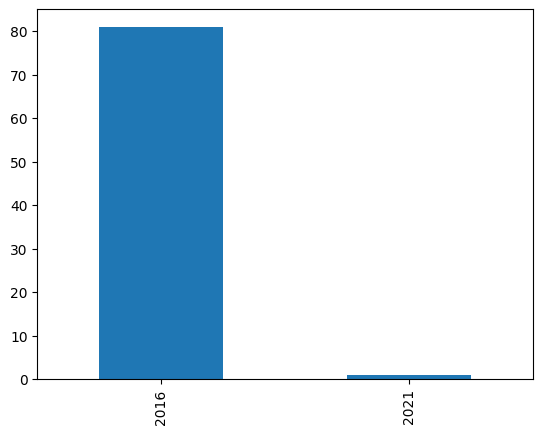

In [9]:
# Campos: ['Número Pasaporte', 'Fecha Emisión', 'Número Trámite', 'Tipo Trámite']

df_1['yyyy-MM'] = df_1['Fecha Emisión'].dt.strftime('%Y-%m')
df_1['yyyy'] = df_1['Fecha Emisión'].dt.strftime('%Y')

df_1_1 = df_1.groupby(by=['yyyy']).agg({ 'Número Pasaporte': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_1_1.plot.bar(legend=False, xlabel='')

### 3.2 Se define como regla, que cada persona debe tener una única nacionalidad registrada en el control migratorio.

In [13]:
# Extracción
df_2 = pd.read_excel('./data/A2.xlsx')

<Axes: >

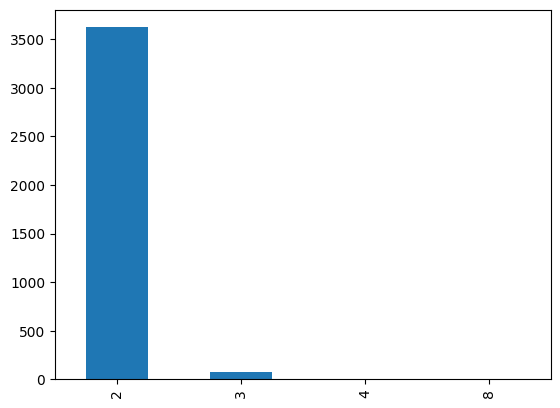

In [16]:
# Campos: ['Cantidad Nacionalidades', 'Nacionalidades']

df_1_2 = df_2.groupby(by=['Cantidad Nacionalidades']).agg({ 'Cantidad Nacionalidades': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_1_2.plot.bar(legend=False, xlabel='')

### 3.3 Se define como regla que cada ciudadano debe tener un único registro de control migratorio en una sola dependencia.

In [18]:
# Extracción
df_3 = pd.read_excel('./data/A3.xlsx')

<Axes: >

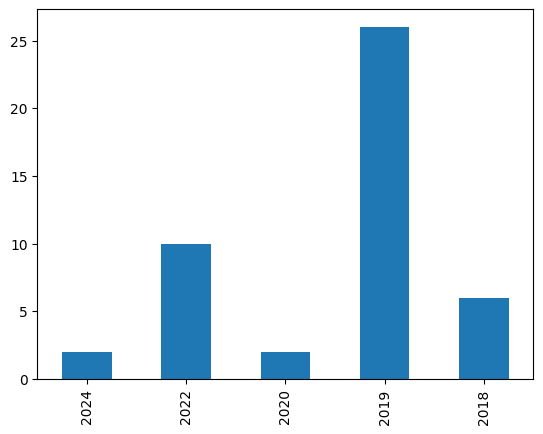

In [22]:
# Campos: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia']

df_3['nAñoControl'] = df_3['Fecha Control'].dt.year

df_1_3 = df_3.groupby(by=['nAñoControl']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='nAñoControl', ascending=False) \
             .head(5)

df_1_3.plot.bar(legend=False, xlabel='')

### 3.4 Se define como regla que cada ciudadano debe tener un único registro de control migratorio en una solo módulo.

In [24]:
# Extracción
df_4 = pd.read_excel('./data/A4.xlsx')

<Axes: >

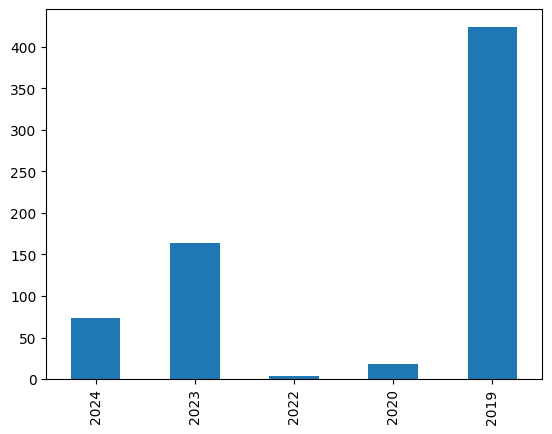

In [ ]:
# Campos: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia']

df_4['nAñoControl'] = df_4['Fecha Control'].dt.year

df_1_4 = df_4.groupby(by=['nAñoControl']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='nAñoControl', ascending=False) \
             .head(5)

df_1_4.plot.bar(legend=False, xlabel='')

### 3.5 Se define como regla, que cada ciudadano debe tener un único registro de control migratorio asociado a una sola vía de transporte.

In [30]:
# Extracción
df_5 = pd.read_excel('./data/A5.xlsx')

<Axes: >

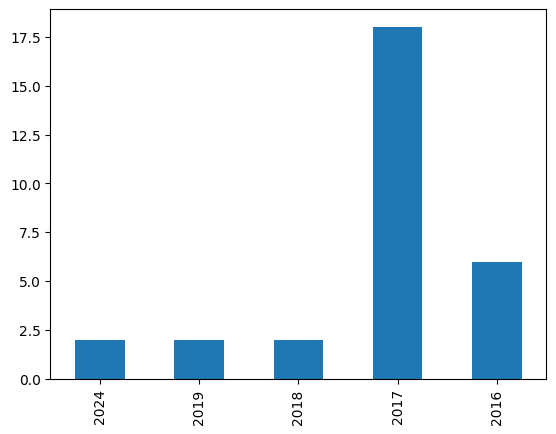

In [31]:
df_5['nAñoControl'] = df_5['Fecha Control'].dt.year

df_1_5 = df_5.groupby(by=['nAñoControl']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='nAñoControl', ascending=False) \
             .head(5)

df_1_5.plot.bar(legend=False, xlabel='')

### 3.6 Se define como regla, que un documento de identidad (DNI) debe ser utilizado por una sola persona.

In [4]:
# Extracción
df_6 = pd.read_excel('./data/A6.xlsx')

<Axes: >

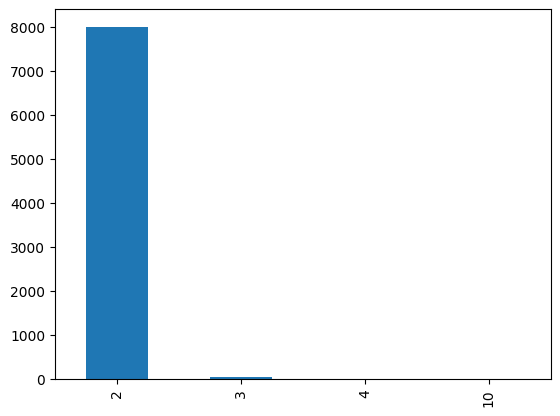

In [18]:
# ['Doc Identidad', 'Num Doc Identidad']

df_1_6 = df_6.groupby(by=['Num Doc Identidad']).agg({ 'Num Doc Identidad': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .groupby(by=['count']).agg({ 'count': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .iloc[1:]
             
df_1_6.plot.bar(legend=False, xlabel='')

### 3.7 Se define como regla, que un operador no debe realizar el registro de control migratorio en más de una dependencia en la misma fecha, hora y minuto.

In [22]:
df_7 = pd.read_excel('./data/A7.xlsx')

<Axes: >

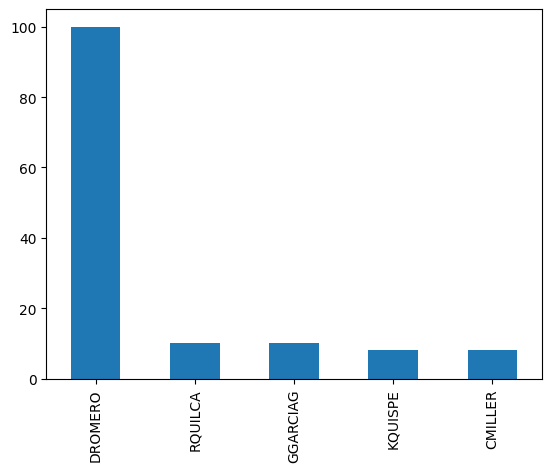

In [27]:
# ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Operador Digita']
df_7_1 = df_7.groupby(by=['Operador Digita']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_7_1.plot.bar(legend=False, xlabel='')

### 3.8 Se define como regla, que todos los itinerarios en estado cerrado o programado deben tener al menos un pasajero.

In [28]:
df_8 = pd.read_excel('./data/A8.xlsx')

<Axes: >

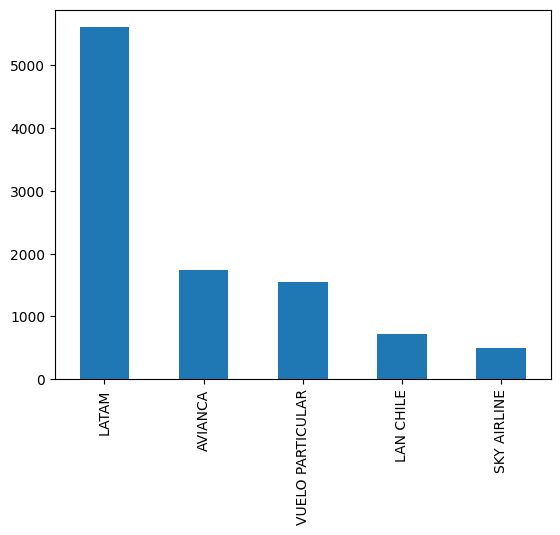

In [30]:
# ['Id Itinerario', 'Fecha Control', 'Número Nave', 'Empresa Transporte', 'Tipo Movimiento', 'Estado Itinerario', 'Cantidad Mov']

df_8_1 = df_8.groupby(by=['Empresa Transporte']).agg({ 'Id Itinerario': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_8_1.plot.bar(legend=False, xlabel='')